# Head-Level Circuit Recovery Analysis

Maps SAE features → attention heads, then aggregates feature-level edges (from PC, GES, Attribution) to head-level edges.
Checks whether the known GPT-2 induction circuit (L0H0/H1 → L1H5/H6, Olsson et al. 2022) is recovered.

In [8]:
import os
import numpy as np
import pickle
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

PROJECT_DIR = '.'
DATA_DIR    = f'{PROJECT_DIR}/data/pgm-final/data'
ACT_DIR     = f'{PROJECT_DIR}/data/pgm-final/activations'
RESULTS_DIR = f'{PROJECT_DIR}/data/pgm-final/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [9]:
from transformer_lens import HookedTransformer
from sae_lens import SAE

model = HookedTransformer.from_pretrained_no_processing('gpt2').to(DEVICE)
model.eval()

sae_L1, _, _ = SAE.from_pretrained('gpt2-small-res-jb', 'blocks.1.hook_resid_pre', device=DEVICE)
sae_L2, _, _ = SAE.from_pretrained('gpt2-small-res-jb', 'blocks.2.hook_resid_pre', device=DEVICE)

print('Model + SAEs loaded')
print(f'  W_enc L1: {sae_L1.W_enc.shape}')   # (d_model, n_features)
print(f'  W_enc L2: {sae_L2.W_enc.shape}')

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9776.16it/s]


Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps


/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_16251/4106869563.py:7: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_L1, _, _ = SAE.from_pretrained('gpt2-small-res-jb', 'blocks.1.hook_resid_pre', device=DEVICE)


Model + SAEs loaded
  W_enc L1: torch.Size([768, 24576])
  W_enc L2: torch.Size([768, 24576])


/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_16251/4106869563.py:8: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_L2, _, _ = SAE.from_pretrained('gpt2-small-res-jb', 'blocks.2.hook_resid_pre', device=DEVICE)


In [10]:
import json

indices_L1 = np.load(f'{ACT_DIR}/indices_L1.npy')   # shape (N_L1,)
indices_L2 = np.load(f'{ACT_DIR}/indices_L2.npy')   # shape (N_L2,)
N_L1, N_L2 = len(indices_L1), len(indices_L2)

with open(f'{ACT_DIR}/metadata.json') as f:
    meta = json.load(f)

print(f'N_L1={N_L1}, N_L2={N_L2}')
print(f'indices_L1[:5]: {indices_L1[:5]}')
print(f'indices_L2[:5]: {indices_L2[:5]}')

N_L1=30, N_L2=46
indices_L1[:5]: [ 482  567 1153 1230 2064]
indices_L2[:5]: [ 878 1620 2325 2632 3545]


## 1. Collect Per-Head Outputs

Hook `blocks.0.attn.hook_result` and `blocks.1.attn.hook_result`.
Each returns shape `(batch, seq, n_heads, d_head)`. We use the last token position.

In [11]:
CACHE_HEADS = f'{RESULTS_DIR}/head_outputs.npz'
BATCH       = 64
POS         = -1   # last token position

if os.path.exists(CACHE_HEADS):
    _d = np.load(CACHE_HEADS)
    head_out_L0 = _d['head_out_L0']   # (N, 12, d_model)
    head_out_L1 = _d['head_out_L1']
    print(f'Loaded cached head outputs: L0={head_out_L0.shape}, L1={head_out_L1.shape}')
else:
    prompts_np = np.load(f'{DATA_DIR}/prompts.npy')
    prompts    = torch.from_numpy(prompts_np).to(DEVICE)
    N          = len(prompts)

    # hook_z is always available: (batch, seq, n_heads, d_head)
    # Project through W_O to get each head's contribution in d_model space.
    # W_O shape: (n_heads, d_head, d_model)
    W_O_L0 = model.blocks[0].attn.W_O.detach().float().cpu().numpy()  # (12, d_head, d_model)
    W_O_L1 = model.blocks[1].attn.W_O.detach().float().cpu().numpy()

    all_L0 = []
    all_L1 = []

    for start in tqdm(range(0, N, BATCH), desc='Collecting head outputs'):
        batch = prompts[start:start+BATCH]
        store = {}

        def hook_L0(value, hook):
            # value: (batch, seq, n_heads, d_head) — grab last position
            store['L0'] = value[:, POS, :, :].detach().float().cpu()
            return value

        def hook_L1(value, hook):
            store['L1'] = value[:, POS, :, :].detach().float().cpu()
            return value

        with torch.no_grad():
            model.run_with_hooks(
                batch,
                fwd_hooks=[
                    ('blocks.0.attn.hook_z', hook_L0),
                    ('blocks.1.attn.hook_z', hook_L1),
                ]
            )

        # z: (batch, n_heads, d_head)  ×  W_O: (n_heads, d_head, d_model)
        # → (batch, n_heads, d_model)
        z0 = store['L0'].numpy()   # (batch, 12, d_head)
        z1 = store['L1'].numpy()
        out0 = np.einsum('bhd,hde->bhe', z0, W_O_L0)   # (batch, 12, d_model)
        out1 = np.einsum('bhd,hde->bhe', z1, W_O_L1)

        all_L0.append(out0)
        all_L1.append(out1)

    head_out_L0 = np.concatenate(all_L0, axis=0)   # (N, 12, d_model)
    head_out_L1 = np.concatenate(all_L1, axis=0)

    np.savez(CACHE_HEADS, head_out_L0=head_out_L0, head_out_L1=head_out_L1)
    print(f'Saved head outputs: L0={head_out_L0.shape}, L1={head_out_L1.shape}')


Saved head outputs: L0=(5000, 12, 768), L1=(5000, 12, 768)


## 2. Head → Feature Attribution

For each attention head h and each filtered SAE feature f:
```
attr_L0_L1[h, f] = mean_over_tokens( head_out_L0[:, h, :] @ W_enc_L1[:, indices_L1[f]] )
```
This gives the average dot-product between what the head writes and the SAE encoder direction.
The sign doesn't matter for assignment — we take argmax of |attr|.

In [12]:
# SAE encoder weights: W_enc shape is (d_model, n_sae_features)
W_enc_L1 = sae_L1.W_enc.detach().float().cpu().numpy()   # (d_model, 24576)
W_enc_L2 = sae_L2.W_enc.detach().float().cpu().numpy()

# Slice to only the filtered features
W_enc_L1_filt = W_enc_L1[:, indices_L1]   # (d_model, N_L1)
W_enc_L2_filt = W_enc_L2[:, indices_L2]   # (d_model, N_L2)

# attr_L0_L1[h, f] = mean_n( head_out_L0[n, h, :] @ W_enc_L1_filt[:, f] )
# head_out_L0: (N, 12, d_head)  x  W_enc_L1_filt: (d_head, N_L1)
# => (N, 12, N_L1) then mean over axis 0

print('Computing head→feature attribution (L0→L1)...')
attr_L0_L1 = np.einsum('nhd,df->nhf', head_out_L0, W_enc_L1_filt).mean(axis=0)   # (12, N_L1)

print('Computing head→feature attribution (L1→L2)...')
attr_L1_L2 = np.einsum('nhd,df->nhf', head_out_L1, W_enc_L2_filt).mean(axis=0)   # (12, N_L2)

print(f'attr_L0_L1: {attr_L0_L1.shape}  (min={attr_L0_L1.min():.4f}, max={attr_L0_L1.max():.4f})')
print(f'attr_L1_L2: {attr_L1_L2.shape}  (min={attr_L1_L2.min():.4f}, max={attr_L1_L2.max():.4f})')

Computing head→feature attribution (L0→L1)...
Computing head→feature attribution (L1→L2)...
attr_L0_L1: (12, 30)  (min=-1.3857, max=4.2846)
attr_L1_L2: (12, 46)  (min=-4.4195, max=7.3045)


In [13]:
# Assign each L1 feature → dominant L0 head (argmax of |attr| over 12 heads)
feat_to_head_L0 = np.abs(attr_L0_L1).argmax(axis=0)   # (N_L1,)  values in 0..11
feat_to_head_L1 = np.abs(attr_L1_L2).argmax(axis=0)   # (N_L2,)  values in 0..11

print('L1 feature → dominant L0 head:')
for h in range(12):
    n = (feat_to_head_L0 == h).sum()
    print(f'  L0H{h:02d}: {n} features')

print('\nL2 feature → dominant L1 head:')
for h in range(12):
    n = (feat_to_head_L1 == h).sum()
    print(f'  L1H{h:02d}: {n} features')

# Save assignments
np.save(f'{RESULTS_DIR}/feat_to_head_L0.npy', feat_to_head_L0)
np.save(f'{RESULTS_DIR}/feat_to_head_L1.npy', feat_to_head_L1)

L1 feature → dominant L0 head:
  L0H00: 0 features
  L0H01: 0 features
  L0H02: 0 features
  L0H03: 1 features
  L0H04: 0 features
  L0H05: 0 features
  L0H06: 0 features
  L0H07: 2 features
  L0H08: 3 features
  L0H09: 20 features
  L0H10: 3 features
  L0H11: 1 features

L2 feature → dominant L1 head:
  L1H00: 0 features
  L1H01: 3 features
  L1H02: 20 features
  L1H03: 1 features
  L1H04: 2 features
  L1H05: 0 features
  L1H06: 0 features
  L1H07: 0 features
  L1H08: 0 features
  L1H09: 0 features
  L1H10: 20 features
  L1H11: 0 features


## 3. Load All Method Edge Sets

In [14]:
# Load cached results
with open(f'{RESULTS_DIR}/pc_fisherz_results.pkl', 'rb') as f:
    results_fz = pickle.load(f)

with open(f'{RESULTS_DIR}/pc_gsq_results.pkl', 'rb') as f:
    results_gsq = pickle.load(f)

with open(f'{RESULTS_DIR}/ges_results.pkl', 'rb') as f:
    ges_cache = pickle.load(f)

# Attribution edges (95th-percentile threshold)
attribution_matrix = np.load(f'{RESULTS_DIR}/attribution_matrix.npy')   # (N_L1, N_L2)
threshold_95 = np.percentile(attribution_matrix, 95)
edges_attr_95 = {(i, j + N_L1)
                 for i in range(N_L1)
                 for j in range(N_L2)
                 if attribution_matrix[i, j] >= threshold_95}

# Collect all edge sets
edges_fz   = results_fz.get('edges', set())
edges_gsq  = results_gsq.get('edges', set())
edges_bic  = ges_cache.get('edges_bic', set())
edges_attr = edges_attr_95

print(f'PC-FisherZ:    {len(edges_fz):4d} edges')
print(f'PC-GSq:        {len(edges_gsq):4d} edges')
print(f'GES-BIC:       {len(edges_bic):4d} edges')
print(f'Attribution:   {len(edges_attr):4d} edges')

all_methods = {
    'PC-FisherZ': edges_fz,
    'PC-GSq':     edges_gsq,
    'GES-BIC':    edges_bic,
    'Attribution':edges_attr,
}

PC-FisherZ:       0 edges
PC-GSq:           0 edges
GES-BIC:        157 edges
Attribution:     69 edges


## 4. Aggregate Feature Edges → Head-Level Edges

In [15]:
def edges_to_head_matrix(edges, feat_to_head_L0, feat_to_head_L1, N_L1):
    """Convert feature-level edges (i, j) to a 12×12 head-level count matrix."""
    mat = np.zeros((12, 12), dtype=int)
    for (i, j) in edges:
        if i >= N_L1 or j < N_L1:
            continue   # skip if not L1→L2 edge
        h0 = feat_to_head_L0[i]         # which L0 head drives L1 feature i
        h1 = feat_to_head_L1[j - N_L1]  # which L1 head drives L2 feature j
        mat[h0, h1] += 1
    return mat

head_matrices = {}
for name, edges in all_methods.items():
    head_matrices[name] = edges_to_head_matrix(edges, feat_to_head_L0, feat_to_head_L1, N_L1)
    print(f'{name}: total head-level edge weight = {head_matrices[name].sum()}')

PC-FisherZ: total head-level edge weight = 0
PC-GSq: total head-level edge weight = 0
GES-BIC: total head-level edge weight = 157
Attribution: total head-level edge weight = 69


## 5. Heatmaps with Known Induction Circuit Highlighted

Known induction circuit (Olsson et al. 2022):
- **Prev-token heads**: L0H0, L0H1
- **Induction heads**: L1H5, L1H6

Red boxes highlight the 4 cells {(h0, h1) : h0 ∈ {0,1}, h1 ∈ {5,6}}.

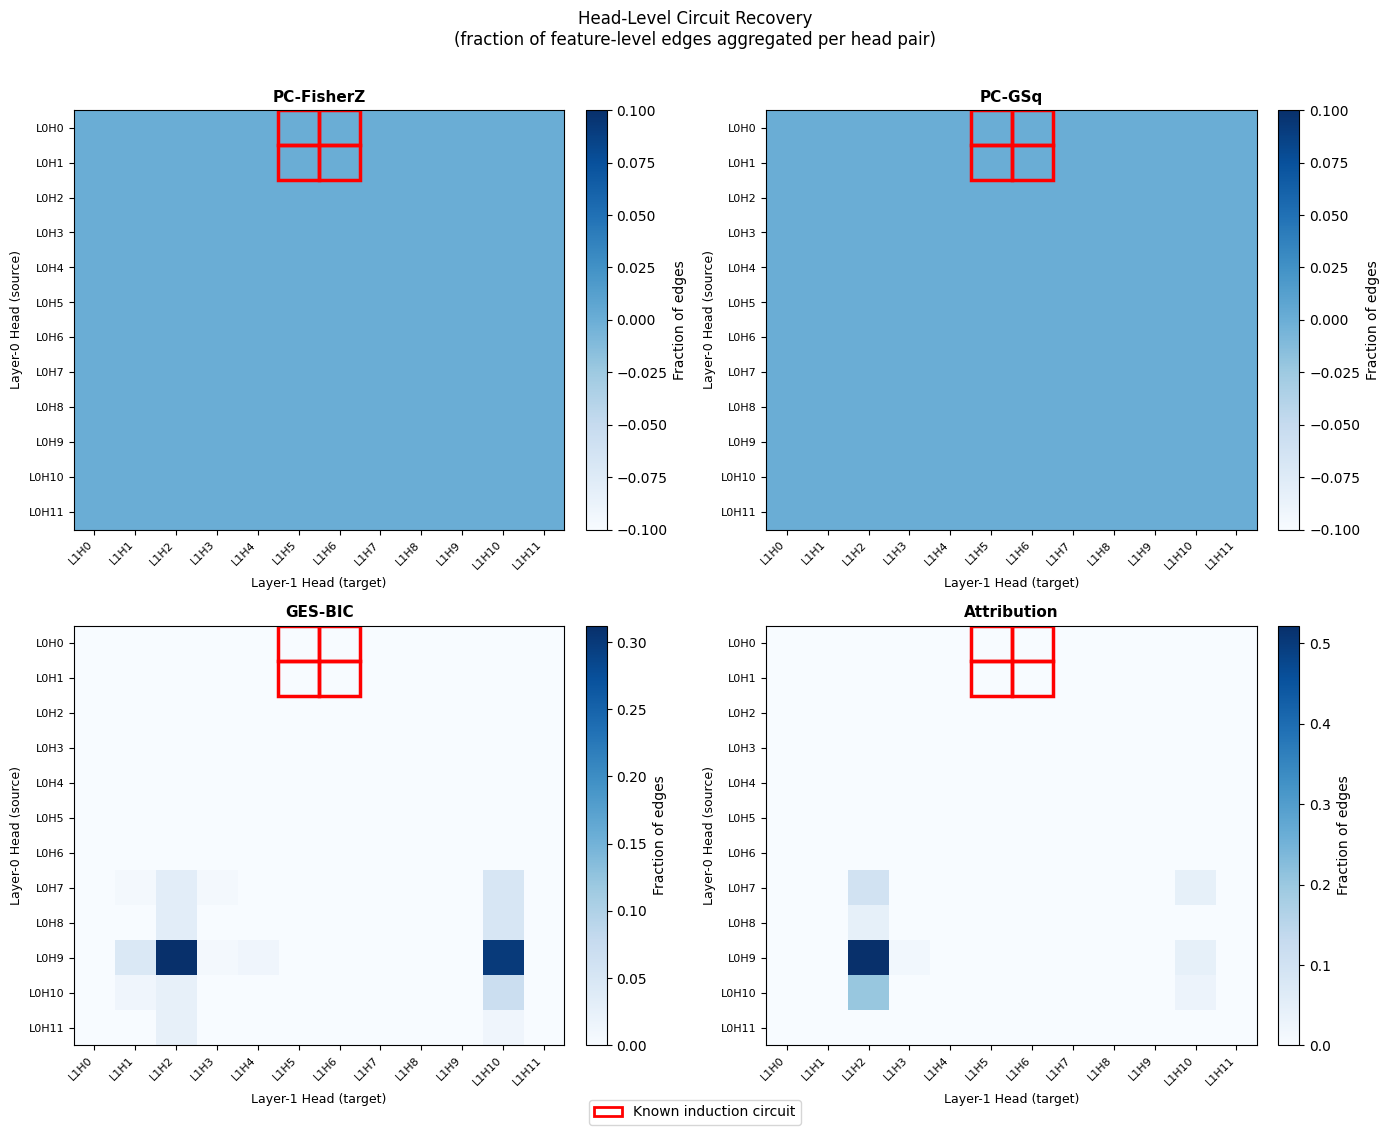

Saved heatmaps.


In [16]:
KNOWN_L0 = [0, 1]   # prev-token heads in layer 0
KNOWN_L1 = [5, 6]   # induction heads in layer 1

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, mat) in zip(axes, head_matrices.items()):
    # Normalize so we can compare methods with different edge counts
    total = mat.sum() or 1
    norm_mat = mat / total

    im = ax.imshow(norm_mat, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Fraction of edges')

    # Red boxes on known induction circuit cells
    for h0 in KNOWN_L0:
        for h1 in KNOWN_L1:
            rect = mpatches.FancyBboxPatch(
                (h1 - 0.5, h0 - 0.5), 1, 1,
                linewidth=2.5, edgecolor='red', facecolor='none',
                boxstyle='square,pad=0'
            )
            ax.add_patch(rect)

    ax.set_xticks(range(12))
    ax.set_yticks(range(12))
    ax.set_xticklabels([f'L1H{h}' for h in range(12)], rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels([f'L0H{h}' for h in range(12)], fontsize=8)
    ax.set_xlabel('Layer-1 Head (target)', fontsize=9)
    ax.set_ylabel('Layer-0 Head (source)', fontsize=9)
    ax.set_title(name, fontsize=11, fontweight='bold')

red_patch = mpatches.Patch(edgecolor='red', facecolor='none', linewidth=2, label='Known induction circuit')
fig.legend(handles=[red_patch], loc='lower center', ncol=1, fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Head-Level Circuit Recovery\n(fraction of feature-level edges aggregated per head pair)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/head_level_heatmaps.pdf', bbox_inches='tight')
plt.savefig(f'{RESULTS_DIR}/head_level_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved heatmaps.')

## 6. Quantitative Recovery Statistics

In [17]:
import pandas as pd

rows = []
for name, mat in head_matrices.items():
    total = mat.sum() or 1

    # Weight on the 4 known induction circuit cells
    induction_weight = sum(mat[h0, h1] for h0 in KNOWN_L0 for h1 in KNOWN_L1)
    induction_frac   = induction_weight / total

    # Expected fraction under uniform (4 out of 144 cells)
    uniform_frac = 4 / 144

    # Enrichment ratio
    enrichment = induction_frac / uniform_frac if uniform_frac > 0 else 0

    # Whether any induction cell is in the top-5 head pairs
    flat_idx   = np.argsort(mat.flatten())[::-1]
    top5_pairs = [(idx // 12, idx % 12) for idx in flat_idx[:5]]
    any_in_top5 = any(h0 in KNOWN_L0 and h1 in KNOWN_L1 for h0, h1 in top5_pairs)

    rows.append({
        'Method':           name,
        'Total edges':      total,
        'Induction weight': induction_weight,
        'Induction frac':   f'{induction_frac:.3f}',
        'Uniform frac':     f'{uniform_frac:.3f}',
        'Enrichment':       f'{enrichment:.2f}×',
        'In top-5 pairs':   any_in_top5,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(f'{RESULTS_DIR}/head_level_recovery.csv', index=False)
print('\nSaved to head_level_recovery.csv')

     Method  Total edges  Induction weight Induction frac Uniform frac Enrichment  In top-5 pairs
 PC-FisherZ            1                 0          0.000        0.028      0.00×           False
     PC-GSq            1                 0          0.000        0.028      0.00×           False
    GES-BIC          157                 0          0.000        0.028      0.00×           False
Attribution           69                 0          0.000        0.028      0.00×           False

Saved to head_level_recovery.csv


In [18]:
# Show exact counts for the 4 known cells per method
print('Counts at known induction circuit cells (L0H{0,1} → L1H{5,6}):\n')
header = f'{"":15s}' + ''.join(f'  L0H{h}→L1H{h1}' for h in KNOWN_L0 for h1 in KNOWN_L1)
print(header)
print('-' * len(header))
for name, mat in head_matrices.items():
    vals = ''.join(f'  {mat[h0,h1]:>12d}' for h0 in KNOWN_L0 for h1 in KNOWN_L1)
    print(f'{name:15s}{vals}')

Counts at known induction circuit cells (L0H{0,1} → L1H{5,6}):

                 L0H0→L1H5  L0H0→L1H6  L0H1→L1H5  L0H1→L1H6
-----------------------------------------------------------
PC-FisherZ                  0             0             0             0
PC-GSq                      0             0             0             0
GES-BIC                     0             0             0             0
Attribution                 0             0             0             0


In [19]:
# Top-10 head pairs for each method
print('Top-10 head pairs by edge count for each method:')
print('(* = known induction circuit cell)\n')
for name, mat in head_matrices.items():
    print(f'--- {name} ---')
    flat_idx = np.argsort(mat.flatten())[::-1][:10]
    for rank, idx in enumerate(flat_idx, 1):
        h0, h1 = idx // 12, idx % 12
        flag = ' *' if h0 in KNOWN_L0 and h1 in KNOWN_L1 else ''
        print(f'  #{rank:2d}  L0H{h0} → L1H{h1}  ({mat[h0,h1]:3d} edges){flag}')
    print()

Top-10 head pairs by edge count for each method:
(* = known induction circuit cell)

--- PC-FisherZ ---
  # 1  L0H11 → L1H11  (  0 edges)
  # 2  L0H11 → L1H10  (  0 edges)
  # 3  L0H4 → L1H3  (  0 edges)
  # 4  L0H4 → L1H2  (  0 edges)
  # 5  L0H4 → L1H1  (  0 edges)
  # 6  L0H4 → L1H0  (  0 edges)
  # 7  L0H3 → L1H11  (  0 edges)
  # 8  L0H3 → L1H10  (  0 edges)
  # 9  L0H3 → L1H9  (  0 edges)
  #10  L0H3 → L1H8  (  0 edges)

--- PC-GSq ---
  # 1  L0H11 → L1H11  (  0 edges)
  # 2  L0H11 → L1H10  (  0 edges)
  # 3  L0H4 → L1H3  (  0 edges)
  # 4  L0H4 → L1H2  (  0 edges)
  # 5  L0H4 → L1H1  (  0 edges)
  # 6  L0H4 → L1H0  (  0 edges)
  # 7  L0H3 → L1H11  (  0 edges)
  # 8  L0H3 → L1H10  (  0 edges)
  # 9  L0H3 → L1H9  (  0 edges)
  #10  L0H3 → L1H8  (  0 edges)

--- GES-BIC ---
  # 1  L0H9 → L1H2  ( 49 edges)
  # 2  L0H9 → L1H10  ( 47 edges)
  # 3  L0H10 → L1H10  ( 11 edges)
  # 4  L0H7 → L1H10  (  8 edges)
  # 5  L0H8 → L1H10  (  8 edges)
  # 6  L0H9 → L1H1  (  7 edges)
  # 7  L0H8 → 

## 7. Attribution Strength Heatmap

Show the raw head→feature attribution values to verify the feature-to-head assignment is reasonable.

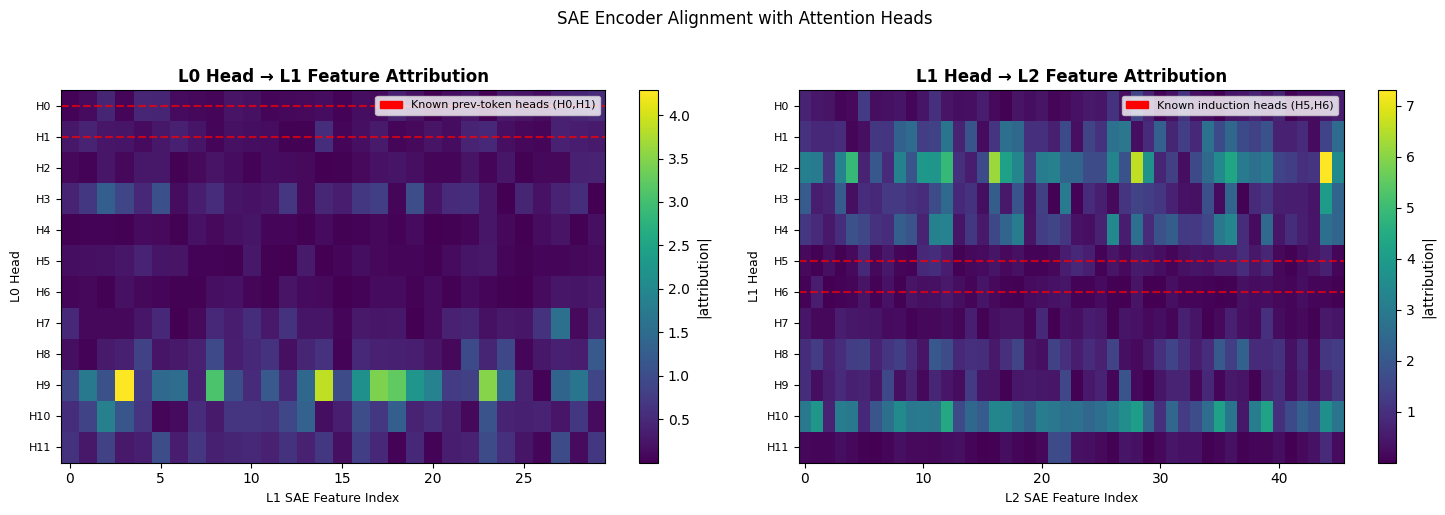

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

im1 = ax1.imshow(np.abs(attr_L0_L1), cmap='viridis', aspect='auto')
plt.colorbar(im1, ax=ax1, label='|attribution|')
ax1.set_xlabel('L1 SAE Feature Index', fontsize=9)
ax1.set_ylabel('L0 Head', fontsize=9)
ax1.set_yticks(range(12))
ax1.set_yticklabels([f'H{h}' for h in range(12)], fontsize=8)
ax1.set_title('L0 Head → L1 Feature Attribution', fontweight='bold')

# Highlight known prev-token heads (L0H0, L0H1)
for h in KNOWN_L0:
    ax1.axhline(h, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.legend(handles=[mpatches.Patch(color='red', label='Known prev-token heads (H0,H1)')],
           loc='upper right', fontsize=8)

im2 = ax2.imshow(np.abs(attr_L1_L2), cmap='viridis', aspect='auto')
plt.colorbar(im2, ax=ax2, label='|attribution|')
ax2.set_xlabel('L2 SAE Feature Index', fontsize=9)
ax2.set_ylabel('L1 Head', fontsize=9)
ax2.set_yticks(range(12))
ax2.set_yticklabels([f'H{h}' for h in range(12)], fontsize=8)
ax2.set_title('L1 Head → L2 Feature Attribution', fontweight='bold')

# Highlight known induction heads (L1H5, L1H6)
for h in KNOWN_L1:
    ax2.axhline(h, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.legend(handles=[mpatches.Patch(color='red', label='Known induction heads (H5,H6)')],
           loc='upper right', fontsize=8)

plt.suptitle('SAE Encoder Alignment with Attention Heads', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/head_attribution_heatmaps.pdf', bbox_inches='tight')
plt.savefig(f'{RESULTS_DIR}/head_attribution_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

Print a concise summary for the paper.

In [21]:
print('=' * 60)
print('HEAD-LEVEL CIRCUIT RECOVERY SUMMARY')
print('=' * 60)
print(f'\nKnown induction circuit (Olsson et al. 2022):')
print(f'  Prev-token heads: L0H{KNOWN_L0}')
print(f'  Induction heads:  L1H{KNOWN_L1}')
print(f'  Circuit cells:    {{(h0,h1) : h0∈{KNOWN_L0}, h1∈{KNOWN_L1}}} = 4 cells')
print(f'\nFeature-to-head assignment:')
print(f'  L1 features → L0 heads: {dict(zip(*np.unique(feat_to_head_L0, return_counts=True)))}')
print(f'  L2 features → L1 heads: {dict(zip(*np.unique(feat_to_head_L1, return_counts=True)))}')
print()
print(df[['Method', 'Induction frac', 'Enrichment', 'In top-5 pairs']].to_string(index=False))
print('\nNote: enrichment = induction_frac / (4/144 uniform baseline)')
print('=' * 60)

HEAD-LEVEL CIRCUIT RECOVERY SUMMARY

Known induction circuit (Olsson et al. 2022):
  Prev-token heads: L0H[0, 1]
  Induction heads:  L1H[5, 6]
  Circuit cells:    {(h0,h1) : h0∈[0, 1], h1∈[5, 6]} = 4 cells

Feature-to-head assignment:
  L1 features → L0 heads: {np.int64(3): np.int64(1), np.int64(7): np.int64(2), np.int64(8): np.int64(3), np.int64(9): np.int64(20), np.int64(10): np.int64(3), np.int64(11): np.int64(1)}
  L2 features → L1 heads: {np.int64(1): np.int64(3), np.int64(2): np.int64(20), np.int64(3): np.int64(1), np.int64(4): np.int64(2), np.int64(10): np.int64(20)}

     Method Induction frac Enrichment  In top-5 pairs
 PC-FisherZ          0.000      0.00×           False
     PC-GSq          0.000      0.00×           False
    GES-BIC          0.000      0.00×           False
Attribution          0.000      0.00×           False

Note: enrichment = induction_frac / (4/144 uniform baseline)
